# Components of Fig 1 in Min et al.
The plots generated in this notebook were combined in ppt to make a visual summary of our manuscript (Figure 1).

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
sys.path.insert(1, '../scripts/03_analytical_prediction')
from tpc_functions_oo import *
tpc_object = tpc_functions()

In [3]:
Tlist = np.linspace(-5, 40, 400)
CTmin_example = 2
B_example = 30
w_enzymatic_example = tpc_object.w_enzymatic(CTmin=CTmin_example, B=B_example, T=Tlist)
w_tpc_example = tpc_object.w_TPC(CTmin=CTmin_example, B=B_example, T=Tlist)
CTmax_example = CTmin_example + B_example
Topt_example = CTmin_example + 2/3 * B_example

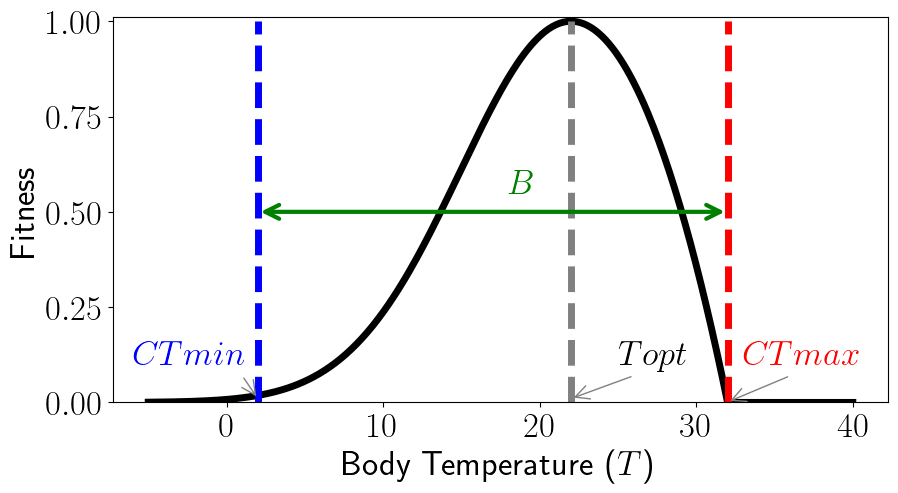

In [4]:
plt.rcParams.update({'font.size': 25})
plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams.update({
    'text.usetex': True,
    'text.latex.preamble': r'\usepackage{amsfonts}'
})
fig, ax = plt.subplots(figsize=(10,5))
ax.plot(Tlist, w_enzymatic_example, linewidth=5, color='k')
ax.set_ylim(0, 1.01)
ax.set_xlabel(r"Body Temperature ($T$)")
ax.set_ylabel("Fitness")
ax.vlines(CTmin_example, ymin=0, ymax=1, linewidth=5, color='b', linestyle='--')
ax.text(-6, 0.1, r"$CTmin$", color='b')
ax.annotate("", xytext=(CTmin_example -1, 0.07), xy=(CTmin_example, 0.01),
            arrowprops=dict(arrowstyle="->", color="grey"))
ax.text(18, 0.55, r"$B$", color='g')
ax.annotate("", xytext=(CTmin_example, 0.5), xy=(CTmin_example + B_example, 0.5),
            arrowprops=dict(arrowstyle="<->", color="g", linewidth=3))
ax.text(25, 0.1, r"$Topt$")
ax.vlines(CTmin_example + 2/3 * B_example, ymin=0, ymax=1, linewidth=5, color='grey', linestyle='--')
ax.annotate("", xytext=(Topt_example+4, 0.07), xy=(Topt_example, 0.01),
            arrowprops=dict(arrowstyle="->", color="grey"))

ax.text(33, 0.1, r"$CTmax$", color='r')
ax.vlines(CTmax_example, ymin=0, ymax=1, linewidth=5, color='r', linestyle='--')
ax.annotate("", xytext=(CTmin_example+B_example+4, 0.07), xy=(CTmin_example+B_example, 0.001),
            arrowprops=dict(arrowstyle="->", color="grey"))
plt.savefig(f"../figures/Fig1a_TPC_components_labeled.png", bbox_inches="tight")

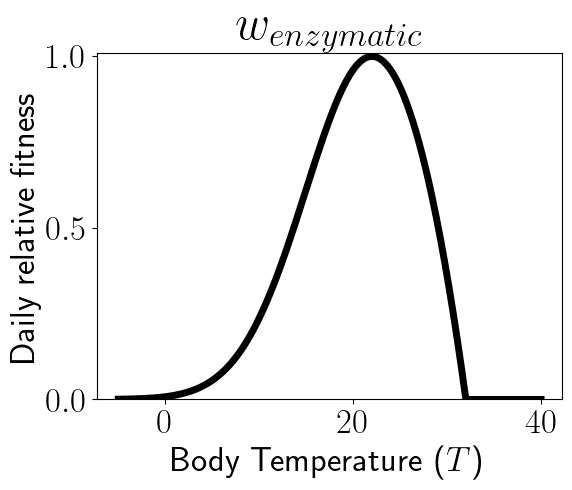

In [5]:
fig, ax = plt.subplots(figsize=(6,4.5))
T_example = 20

ax.plot(Tlist, w_enzymatic_example, linewidth=5, color='k')
ax.set_ylim(0, 1.01)
ax.set_xlabel(r"Body Temperature ($T$)")
ax.set_ylabel("Daily relative fitness")
ax.set_title(r"$w_{enzymatic}$", fontweight='bold', fontsize=35)
fig.savefig("../figures/Fig1b_w_enzymatic.png", bbox_inches="tight")

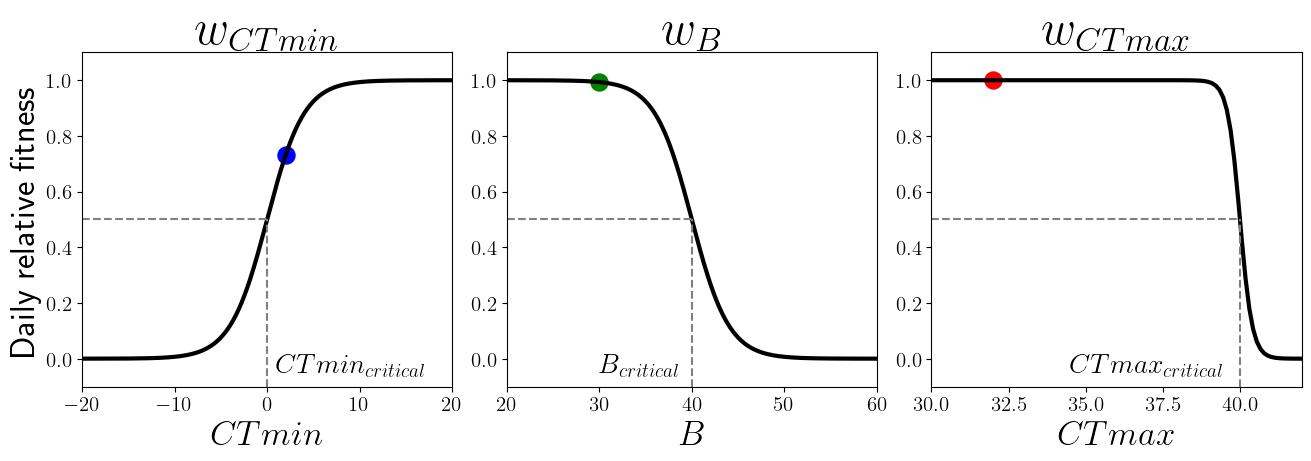

In [6]:
plt.rcParams.update({'font.size': 15})
B_max = 40
DeltaB = 2
CTmin_min = 0
DeltaCTmin = 2
CTmax_max = 40
DeltaCTmax = 0.2
B_list = np.linspace(20, 60, 300)
CTmin_list = np.linspace(-20, 20, 400)
CTmax_list = np.linspace(30, 42, 100)
fig, axes = plt.subplots(nrows=1, ncols=3, figsize = (13, 4.5), constrained_layout=True)

for ax in axes:
    ax.set_ylim((-0.1, 1.1))
# w_CTmin
# axes[0].set_ylabel("Fitness", fontsize=25)
axes[0].set_xlim((CTmin_list[0], CTmin_list[-1]))
axes[0].plot(CTmin_list, tpc_object.w_CTmin(CTmin=CTmin_list), color='k', linewidth=3)
axes[0].set_title(r"$w_{CTmin}$", fontsize=35)
axes[0].set_xlabel("$CTmin$", fontsize=25)
axes[0].set_ylabel("Daily relative fitness", fontsize=25)
axes[0].scatter(CTmin_example, tpc_object.w_CTmin(CTmin=CTmin_example), color='b', s=150)
axes[0].hlines(0.5, xmin=CTmin_list[0], xmax=CTmin_min, color='grey', linestyle='--')
axes[0].vlines(CTmin_min, ymin=-0.1, ymax=0.5, color='grey', linestyle='--')
axes[0].text(1, -0.05, r"$CTmin_{critical}$", fontsize=20)

# w_B
axes[1].set_xlim((B_list[0], B_list[-1]))
axes[1].plot(B_list, tpc_object.w_B(B=B_list), color='k', linewidth=3)
axes[1].set_title(r"$w_{B}$", fontsize=35)
axes[1].set_xlabel("$B$", fontsize=25)
axes[1].scatter(B_example, tpc_object.w_B(B=B_example), color='g', s=150)
axes[1].hlines(0.5, xmin=B_list[0], xmax=B_max, color='grey', linestyle='--')
axes[1].vlines(B_max, ymin=-0.1, ymax=0.5, linestyle='--', color='grey')
axes[1].text(B_max - 10, -0.05, r"$B_{critical}$", fontsize=20)

# w_CTmax
axes[2].plot(CTmax_list, tpc_object.w_CTmax(CTmax=CTmax_list), color='k', linewidth=3)
axes[2].set_xlim((min(CTmax_list), max(CTmax_list)))
axes[2].set_title(r"$w_{CTmax}$", fontsize=35)
axes[2].set_xlabel("$CTmax$", fontsize=25)
axes[2].scatter(CTmax_example, tpc_object.w_CTmax(CTmax=CTmax_example), color='r', s=150)
axes[2].hlines(0.5, xmin=CTmax_list[0], xmax=CTmax_max, color='grey', linestyle='--')
axes[2].vlines(CTmax_max, ymin=-0.1, ymax=0.5, linestyle='--', color='grey')
axes[2].text(CTmax_max - 5.5, -0.05, r"$CTmax_{critical}$", fontsize=20)

fig.savefig("../figures/Fig1b_other_fitness_components.png", bbox_inches="tight")

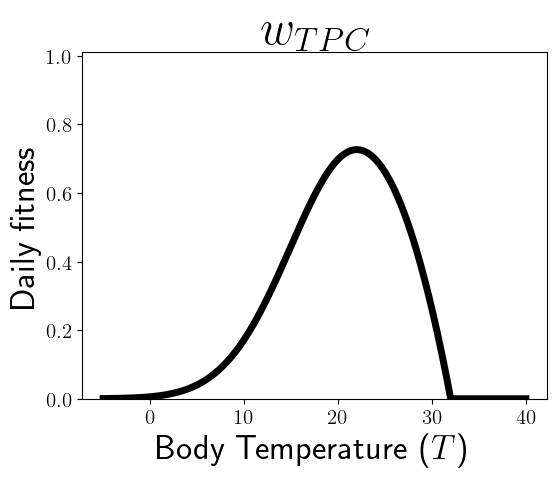

In [7]:
fig, ax = plt.subplots(figsize=(6,4.5))

ax.plot(Tlist, tpc_object.w_TPC(B=B_example, CTmin=CTmin_example, T=Tlist), linewidth=5, color='k')
ax.set_ylim(0, 1.01)
ax.set_xlabel(r"Body Temperature ($T$)", fontsize=25)
ax.set_ylabel("Daily fitness", fontsize=25)

ax.set_title(r"$w_{TPC}$", fontweight='bold', fontsize=35)
fig.savefig("../figures/Fig1b_w_TPC.png", bbox_inches="tight")

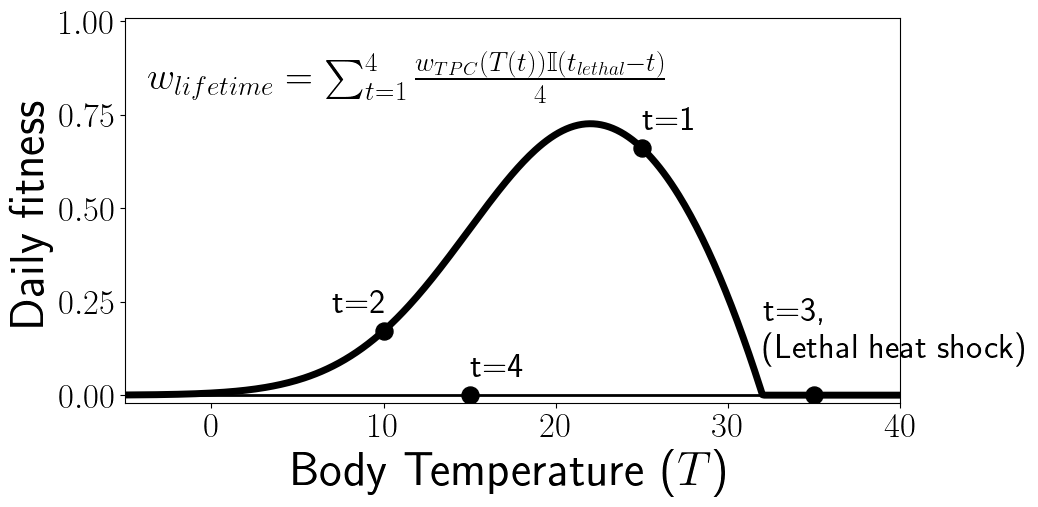

In [8]:
plt.rcParams.update({'font.size': 25})

T_sequence = [25, 10, 35, 15]
TPC_sequence = [tpc_object.w_TPC(CTmin=CTmin_example, B=B_example, T=T_sequence[0]),
               tpc_object.w_TPC(CTmin=CTmin_example, B=B_example, T=T_sequence[1]),
               0,
               0]
fig, ax = plt.subplots(figsize=(10,5))

ax.plot(Tlist, w_tpc_example, linewidth=5, color='k')
ax.plot(Tlist, np.zeros(len(Tlist)), linewidth=2, color='k')

ax.set_ylim(-0.02, 1.01)
ax.set_xlim(Tlist[0], Tlist[-1])

ax.set_xlabel(r"Body Temperature ($T$)", fontsize=35)
ax.scatter(T_sequence, TPC_sequence, color='k', s=150)

ax.set_ylabel("Daily fitness", fontweight='bold', fontsize=35)
ax.text(T_sequence[0], TPC_sequence[0] + 0.05, "t=1", fontsize=25)
ax.text(T_sequence[1]-3, TPC_sequence[1] + 0.05, "t=2", fontsize=25)
ax.text(T_sequence[2]-3, TPC_sequence[2] + 0.1, "t=3, \n(Lethal heat shock)", fontsize=25, fontweight='bold')
ax.text(T_sequence[3], TPC_sequence[3]+0.05, "t=4", fontsize=25)
ax.text(-3.7, 0.82, r"$w_{lifetime}=\sum_{t=1}^4 \frac{w_{TPC}(T(t)) \mathbb{I}(t_{lethal} - t)}{4}$", fontsize=28)
fig.savefig("../figures/Fig1c_fitness_calculation.png", bbox_inches="tight")

In [9]:
analytical_info = np.load("../data/gaussian_MEAN_TEMP_20_STDEV_TEMP_1_analytical_info.npz", allow_pickle=True)

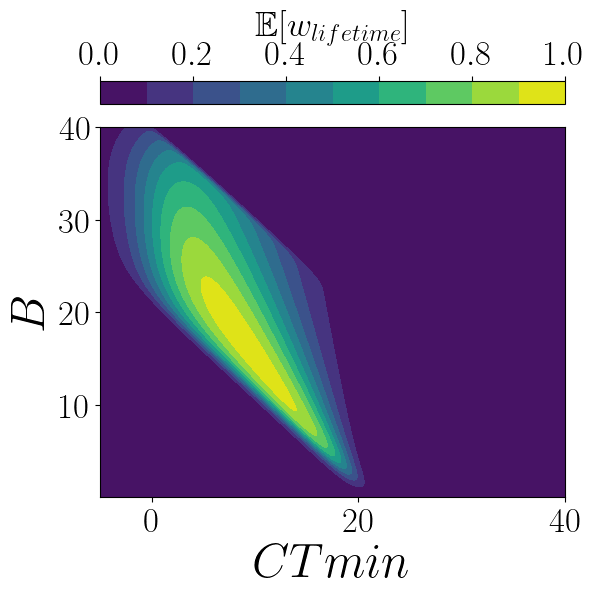

In [10]:
fig, ax = plt.subplots(figsize=(6, 6))
cm = ax.contourf(analytical_info['CTmin_grid'], analytical_info['B_grid'], analytical_info['W_contour'], 
                 levels=np.linspace(0, 1, 11))
ax.set_xlabel(r"$CTmin$", fontsize=35)
ax.set_ylabel(r"$B$", fontsize=35)
fig.colorbar(cm, ax=ax, label=r'$\mathbb{E}[w_{lifetime}]$', location='top')
fig.savefig("../figures/Fig1d_fitness_landscape.png", bbox_inches='tight')

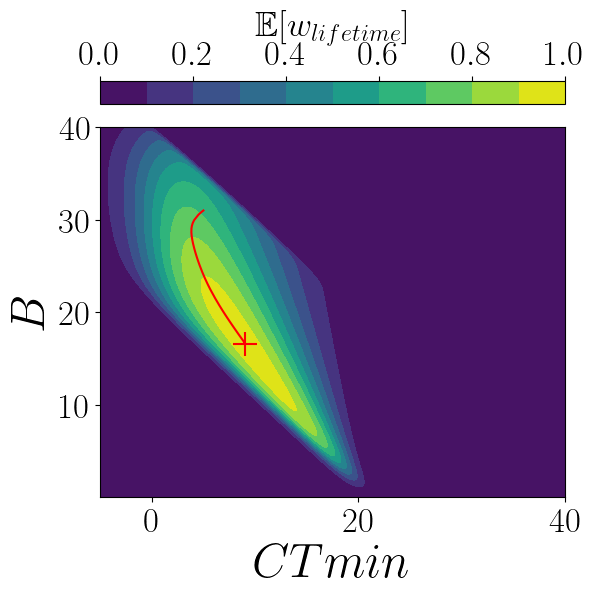

In [11]:
fig, ax = plt.subplots(figsize=(6, 6))
cm = ax.contourf(analytical_info['CTmin_grid'], analytical_info['B_grid'], analytical_info['W_contour'], 
                 levels = np.linspace(0, 1, 11))
ax.plot(analytical_info['sol'].item().y[0], analytical_info['sol'].item().y[1], color='red')
ax.scatter(analytical_info['CTmin_opt'], analytical_info['B_opt'], marker='+', s = 300, color='red')
ax.set_xlabel(r"$CTmin$", fontsize=35)
ax.set_ylabel(r"$B$", fontsize=35)
fig.colorbar(cm, ax=ax, label=r'$\mathbb{E}[w_{lifetime}]$', location='top')
fig.savefig('../figures/Fig1e_trajectory.png', bbox_inches='tight')



In [12]:
VT_temps = pd.read_csv("../slim/VT_weather.txt")

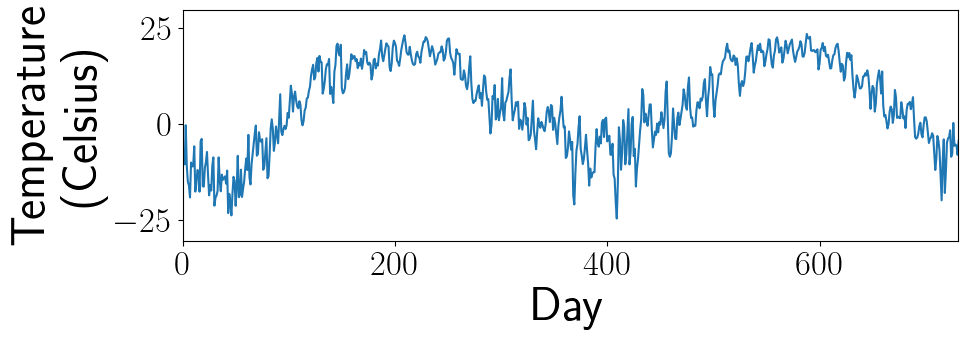

In [13]:
fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(VT_temps.T2M)
ax.set_xlim((0, 365 * 2))
ax.set_xlabel("Day", fontsize=35)
ax.set_ylabel("Temperature\n(Celsius)", fontsize=35)
fig.savefig("../figures/Fig1e_timeseries.png", bbox_inches='tight')